<a href="https://colab.research.google.com/github/bhaweshkk/vois-major-project/blob/main/Seasonal_Agriculture_Performance_Analysis_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Agriculture Performance Analysis

VOIS AICTE Major Project - Data Analytics

Dataset: 4000 farm records, 3 cropping seasons (Kharif / Rabi / Zaid), 28 columns.

Objective: quantify how yield, cost, revenue, profit, water use and disease risk
differ by season, and check whether the differences are consistent enough to act on
(not just an artifact of a few states or a few crops).

Sections: preprocessing -> feature engineering -> seasonal EDA -> significance test -> summary.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 12
pd.set_option('display.max_columns', 30)

# custom palette instead of a seaborn default - roughly monsoon green / winter gold / summer rust,
# matches the three seasons in order so every chart below stays visually consistent
SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']


## Data Preprocessing

In [4]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print(df.shape)
df.head()


(4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [6]:
df.describe().T
# nothing alarming here - no negative costs/revenue, ranges look agronomically sane


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [7]:
missing = df.isnull().sum()
missing[missing > 0]


,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [8]:
print('duplicate rows:', df.duplicated().sum())
print('duplicate Farm_IDs:', df['Farm_ID'].duplicated().sum())


duplicate rows: 0
duplicate Farm_IDs: 0


Missing values are confined to `Rainfall_mm`, `Soil_Moisture_pct`, `Yield_Tonnes_Ha` (~1% each).
Filling with the overall column mean would wash out the seasonal signal this whole
project is built around, so imputing per-season median instead.

In [9]:
cols_to_fill = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']
for col in cols_to_fill:
    df[col] = df.groupby('Season')[col].transform(lambda s: s.fillna(s.median()))

df[cols_to_fill].isnull().sum()


,0
Rainfall_mm,0
Soil_Moisture_pct,0
Yield_Tonnes_Ha,0


Outlier check (IQR, 1.5x rule) - flagging only, not dropping. A crop failure or a
bumper Sugarcane yield is a real seasonal signal, not a data entry error, so removing
extreme values here would defeat the purpose of the analysis.

In [10]:
def count_outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

numeric_cols = df.select_dtypes(include=np.number).columns
outlier_counts = df[numeric_cols].apply(count_outliers_iqr).sort_values(ascending=False)
outlier_counts[outlier_counts > 0]


,0
Profit_INR,404
Production_Tonnes,333
Water_Efficiency_t_per_1000m3,322
Yield_Tonnes_Ha,302
Water_Used_m3,276
Revenue_INR,240
Potassium_kg_ha,32
Sunlight_Hours_Day,26
Phosphorus_kg_ha,16
Fertilizer_kg_ha,15


Counts are small relative to 4000 rows - kept as-is. (Sanity-checked a handful of the
Water_Efficiency outliers manually; several sit at suspiciously round numbers like
50.0 exactly, which smells like a simulated/capped value in the source data rather
than a real farm. Doesn't change the seasonal comparison either way, so leaving it.)

In [11]:
for col in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    df[col] = df[col].str.strip().str.title()

df[['State', 'District', 'Crop', 'Season', 'Irrigation_Method']].nunique()


,0
State,8
District,10
Crop,8
Season,3
Irrigation_Method,4


## Feature Engineering

In [12]:
# profit margin - normalises profit by revenue so farms of very different scale are comparable
df['Profit_Margin_pct'] = df['Profit_INR'] / df['Revenue_INR'] * 100

# cost per tonne produced - a rough efficiency metric
df['Cost_per_Tonne_INR'] = df['Total_Cost_INR'] / df['Production_Tonnes']

# used later for the loss-rate comparison across seasons
df['Is_Loss_Making'] = df['Profit_INR'] < 0

df[['Profit_Margin_pct', 'Cost_per_Tonne_INR', 'Is_Loss_Making']].describe(include='all')


,Profit_Margin_pct,Cost_per_Tonne_INR,Is_Loss_Making
count,4000.000000,4000.000000,4000
unique,NaN,NaN,2
top,NaN,NaN,False
freq,NaN,NaN,2034
mean,-45.492178,55624.858332,NaN
std,158.085472,54260.608703,NaN
min,-1461.851219,568.357511,NaN
25%,-60.192762,23032.641975,NaN
50%,1.146236,37897.601738,NaN
75%,32.885876,64153.096089,NaN


## Exploratory Data Analysis

### Season Distribution

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


/tmp/ipykernel_3181/743178497.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_counts.index, y=season_counts.values, palette=SEASON_COLORS)


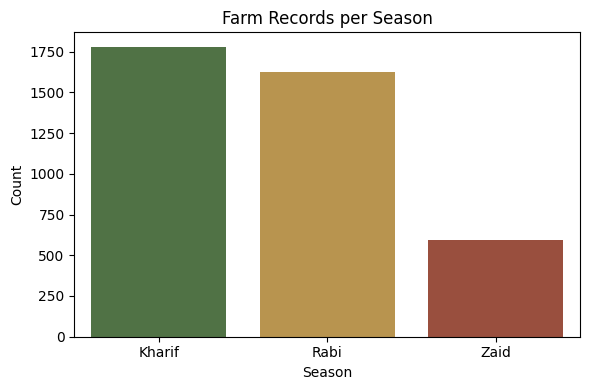

In [13]:
season_counts = df['Season'].value_counts().reindex(SEASON_ORDER)
print(season_counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=season_counts.index, y=season_counts.values, palette=SEASON_COLORS)
plt.title('Farm Records per Season')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


Kharif ~44%, Rabi ~41%, Zaid ~15%. Zaid being the smallest sample tracks with it being
the short summer window squeezed between the two main seasons - keep this in mind before
over-reading any Zaid-specific numbers below.

### Core Metrics by Season

In [14]:
season_summary = df.groupby('Season')[
    ['Yield_Tonnes_Ha', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Profit_Margin_pct']
].mean().round(2).reindex(SEASON_ORDER)
season_summary


,Yield_Tonnes_Ha,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,,
Kharif,5.63,531804.41,710719.06,178914.65,-38.64
Rabi,5.04,513836.58,601526.05,87689.47,-44.27
Zaid,4.64,543976.73,519171.90,-24804.82,-69.35


/tmp/ipykernel_3181/2567926851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=col, estimator=np.mean, order=SEASON_ORDER,
/tmp/ipykernel_3181/2567926851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=col, estimator=np.mean, order=SEASON_ORDER,
/tmp/ipykernel_3181/2567926851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=col, estimator=np.mean, order=SEASON_ORDER,
/tmp/ipykernel_3181/2567926851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` i

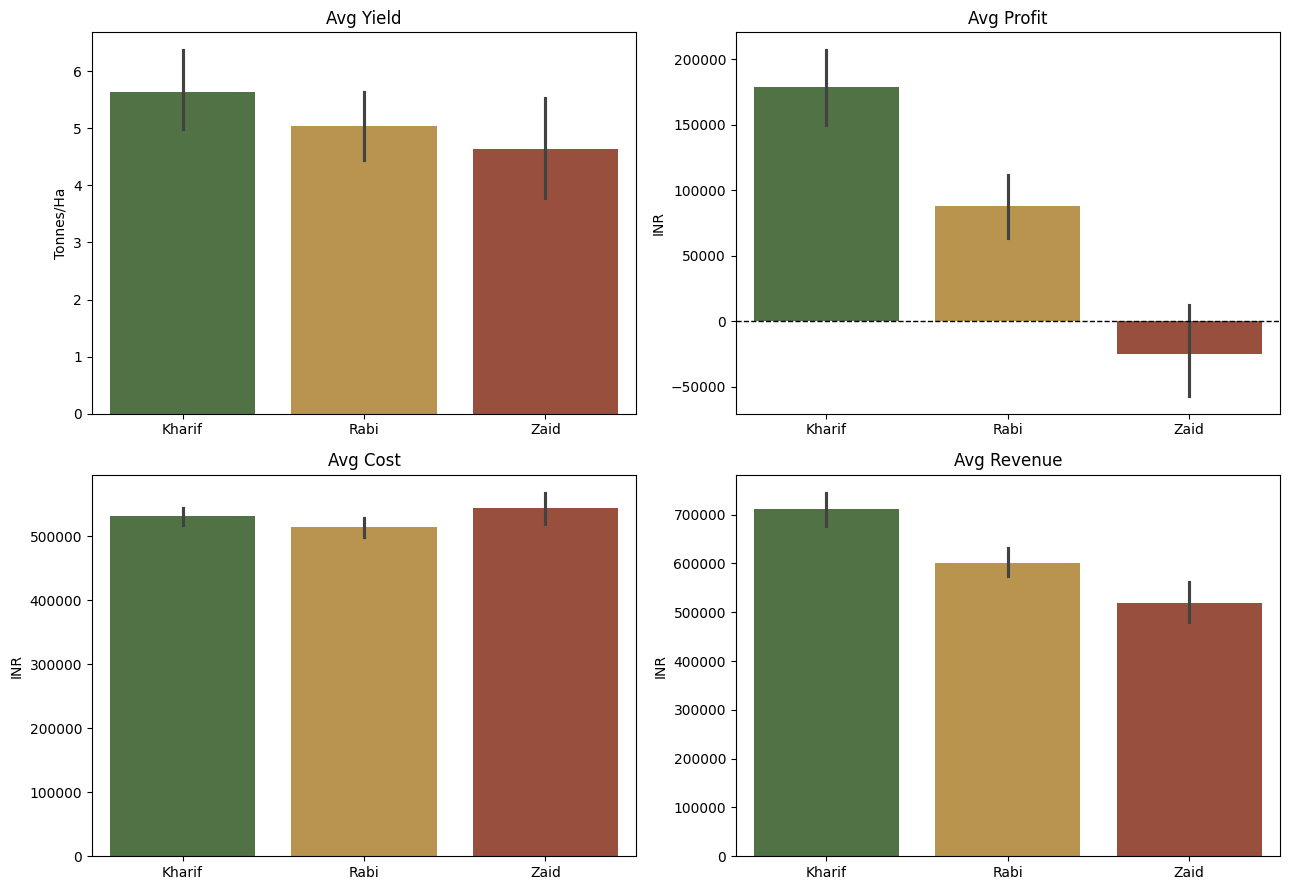

In [15]:
# reusable so the 4 panels below don't turn into 4 near-identical copy-pasted blocks
def season_bar(ax, col, title, ylabel, zero_line=False):
    sns.barplot(data=df, x='Season', y=col, estimator=np.mean, order=SEASON_ORDER,
                palette=SEASON_COLORS, ax=ax)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    if zero_line:
        ax.axhline(0, color='black', linewidth=1, linestyle='--')

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
season_bar(axes[0, 0], 'Yield_Tonnes_Ha', 'Avg Yield', 'Tonnes/Ha')
season_bar(axes[0, 1], 'Profit_INR', 'Avg Profit', 'INR', zero_line=True)
season_bar(axes[1, 0], 'Total_Cost_INR', 'Avg Cost', 'INR')
season_bar(axes[1, 1], 'Revenue_INR', 'Avg Revenue', 'INR')
plt.tight_layout()
plt.show()


Kharif leads on yield and profit. Zaid profit is negative on average despite cost
being roughly flat across seasons - the shortfall is on the revenue side, not spend.

Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Is_Loss_Making, dtype: float64


/tmp/ipykernel_3181/3251413737.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loss_rate.index, y=loss_rate.values, palette=SEASON_COLORS)


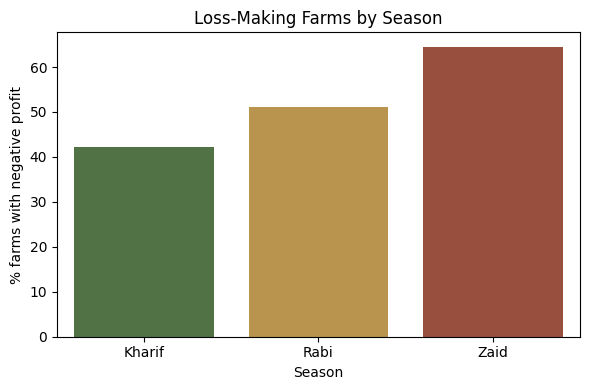

In [16]:
loss_rate = df.groupby('Season')['Is_Loss_Making'].mean().mul(100).round(1).reindex(SEASON_ORDER)
print(loss_rate)

plt.figure(figsize=(6, 4))
sns.barplot(x=loss_rate.index, y=loss_rate.values, palette=SEASON_COLORS)
plt.ylabel('% farms with negative profit')
plt.title('Loss-Making Farms by Season')
plt.tight_layout()
plt.show()


~65% of Zaid farms run at a loss vs under half in Kharif - probably the clearest single
finding in this dataset.

### Environmental Conditions

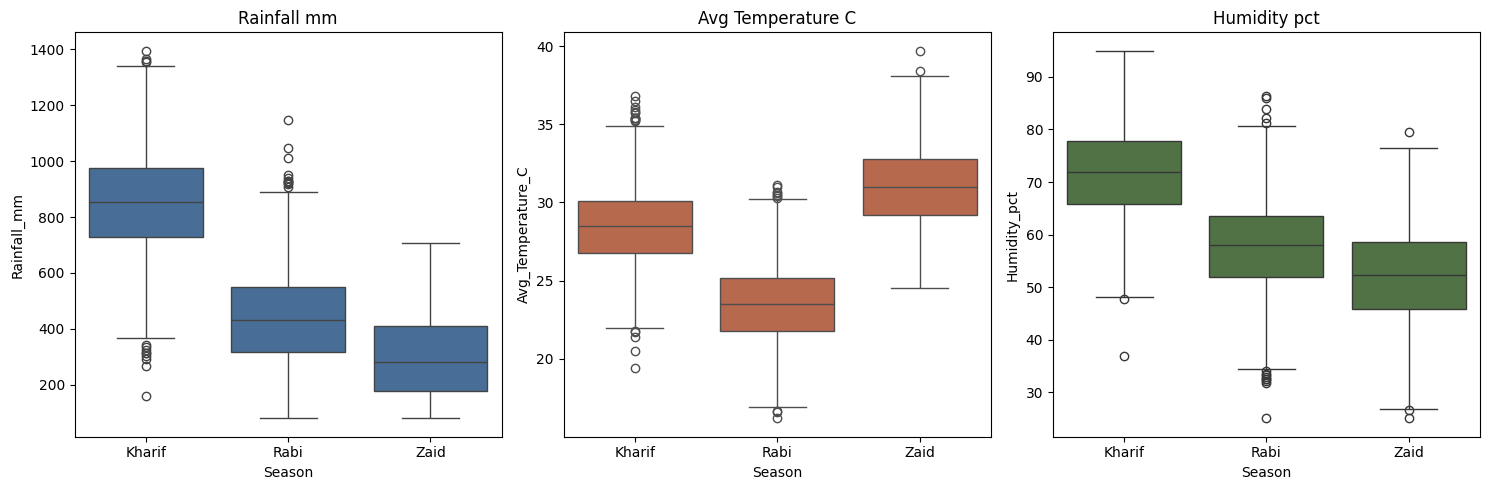

In [17]:
env_colors = ['#3B6EA5', '#C9603C', '#4C7A3D']  # rainfall / temp / humidity

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, color in zip(axes, ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct'], env_colors):
    sns.boxplot(data=df, x='Season', y=col, order=SEASON_ORDER, color=color, ax=ax)
    ax.set_title(col.replace('_', ' '))
plt.tight_layout()
plt.show()


Zaid = hottest, driest of the three. Consistent with it being the irrigation-dependent
summer season - ties into the profit gap above, see irrigation efficiency section.

### Crop x Season Yield

In [18]:
crop_season_yield = df.pivot_table(index='Crop', columns='Season',
                                    values='Yield_Tonnes_Ha', aggfunc='mean').round(2)
crop_season_yield = crop_season_yield[SEASON_ORDER]
crop_season_yield


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.19
Cotton,1.38,1.20,0.96
Groundnut,1.49,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.66
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.28,38.42
Wheat,2.25,2.06,1.75


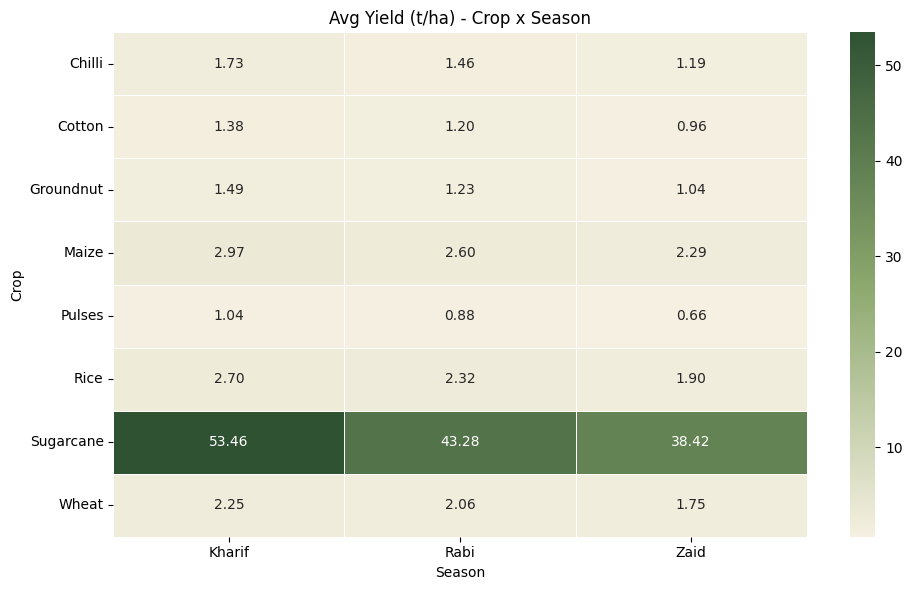

In [19]:
from matplotlib.colors import LinearSegmentedColormap
earth_cmap = LinearSegmentedColormap.from_list('earth', ['#F5F0E1', '#8CA86E', '#2F5233'])

plt.figure(figsize=(10, 6))
sns.heatmap(crop_season_yield, annot=True, fmt='.2f', cmap=earth_cmap, linewidths=0.5)
plt.title('Avg Yield (t/ha) - Crop x Season')
plt.tight_layout()
plt.show()


Sugarcane sits on a totally different scale (tens of t/ha vs low single digits for
everything else) - agronomically normal, but it flattens the color scale for every
other crop, so re-plotting without it below.

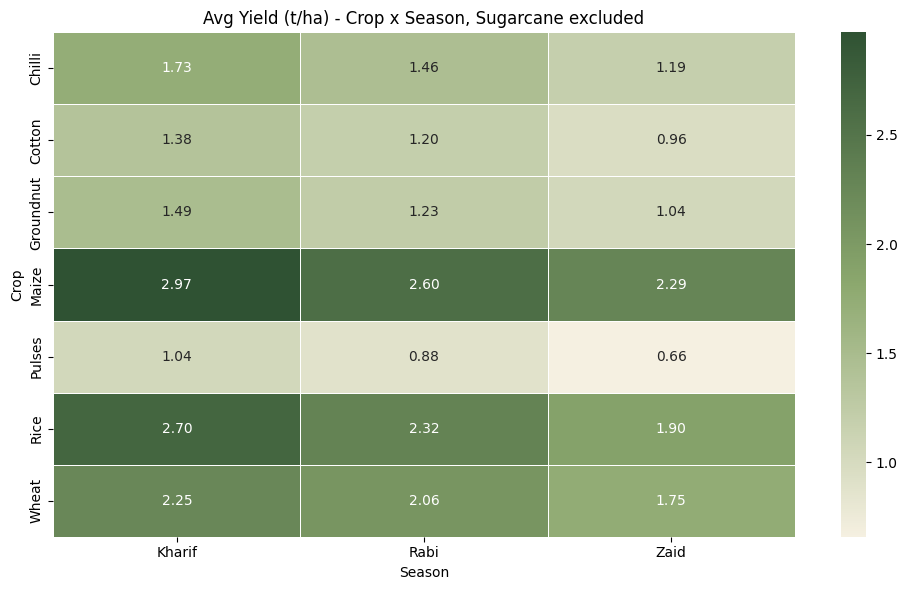

In [20]:
plt.figure(figsize=(10, 6))
sns.heatmap(crop_season_yield.drop('Sugarcane'), annot=True, fmt='.2f',
            cmap=earth_cmap, linewidths=0.5)
plt.title('Avg Yield (t/ha) - Crop x Season, Sugarcane excluded')
plt.tight_layout()
plt.show()


Rice/Maize peak in Kharif, Wheat peaks in Rabi - matches standard sowing calendars
(wheat = winter crop, rice/maize = monsoon crops). Pulses trail in every season.

### Irrigation Efficiency

Irrigation_Method
Rainfed      7.56
Drip         6.27
Sprinkler    4.67
Flood        3.44
Name: Water_Efficiency_t_per_1000m3, dtype: float64


/tmp/ipykernel_3181/419160035.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=irrigation_eff.index, y=irrigation_eff.values,


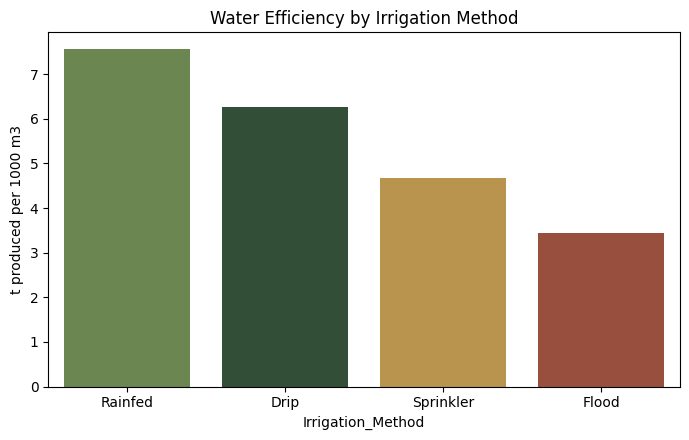

In [21]:
irrigation_colors = {'Drip': '#2F5233', 'Rainfed': '#6B8F47', 'Sprinkler': '#C99A3E', 'Flood': '#A8452F'}

irrigation_eff = (df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3']
                    .mean().sort_values(ascending=False).round(2))
print(irrigation_eff)

plt.figure(figsize=(7, 4.5))
sns.barplot(x=irrigation_eff.index, y=irrigation_eff.values,
            palette=[irrigation_colors.get(m, '#888888') for m in irrigation_eff.index])
plt.title('Water Efficiency by Irrigation Method')
plt.ylabel('t produced per 1000 m3')
plt.tight_layout()
plt.show()


In [22]:
# is Zaid over-reliant on the less efficient methods?
irrigation_mix = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').mul(100).round(1)
irrigation_mix = irrigation_mix.reindex(SEASON_ORDER)
irrigation_mix


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


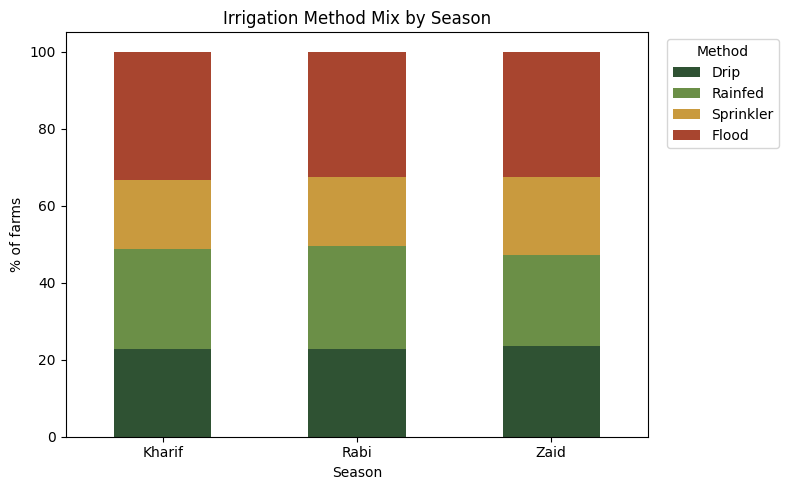

In [23]:
irrigation_mix[list(irrigation_colors.keys())].plot(
    kind='bar', stacked=True, figsize=(8, 5),
    color=[irrigation_colors[m] for m in irrigation_colors])
plt.title('Irrigation Method Mix by Season')
plt.ylabel('% of farms')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Method')
plt.tight_layout()
plt.show()


Drip/Rainfed = most efficient, Flood = worst. Zaid leaning on Flood irrigation while
also getting the least rainfall of the three seasons lines up directly with its weaker
profit numbers - this is probably the single most actionable finding here.

### Disease / Pest Risk

/tmp/ipykernel_3181/2225430028.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER,


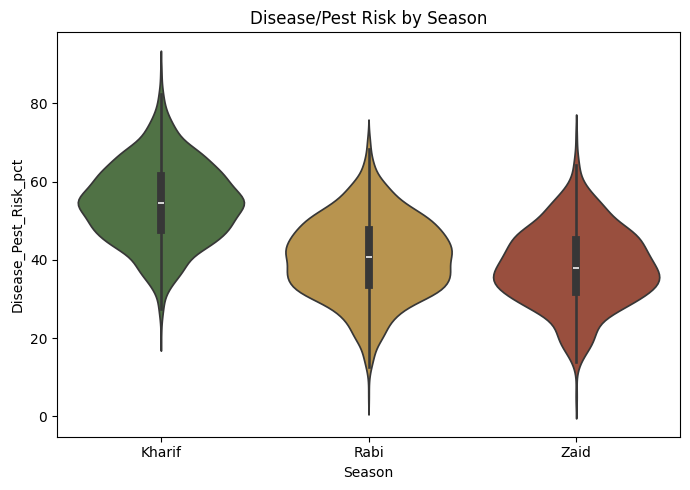

In [24]:
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER,
               palette=SEASON_COLORS)
plt.title('Disease/Pest Risk by Season')
plt.tight_layout()
plt.show()


Kharif has the highest average risk and widest spread - monsoon humidity favours
pests/disease, as expected. Rabi and Zaid are drier and lower-risk.

### Correlation with Yield

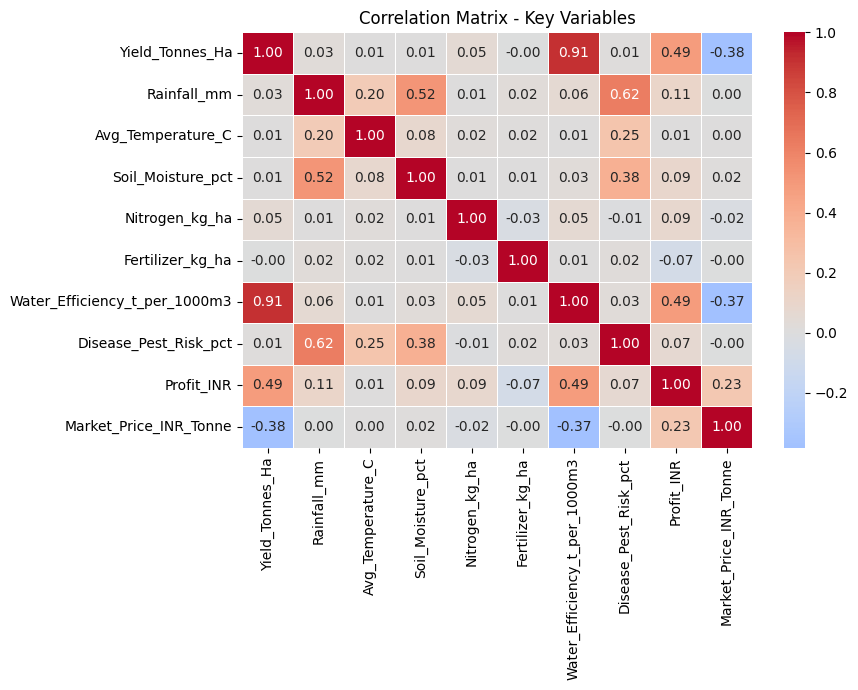

In [25]:
key_cols = ['Yield_Tonnes_Ha', 'Rainfall_mm', 'Avg_Temperature_C', 'Soil_Moisture_pct',
            'Nitrogen_kg_ha', 'Fertilizer_kg_ha', 'Water_Efficiency_t_per_1000m3',
            'Disease_Pest_Risk_pct', 'Profit_INR', 'Market_Price_INR_Tonne']

corr_matrix = df[key_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix - Key Variables')
plt.tight_layout()
plt.show()


`Water_Efficiency_t_per_1000m3` correlates with yield more strongly than fertiliser,
nitrogen or rainfall individually - wasn't expecting it to dominate the others by this
much. `Market_Price_INR_Tonne` correlates negatively with yield, which is just
supply and demand (bumper output -> lower price per tonne) rather than anything wrong
with the data, but worth stating explicitly since it's the non-obvious result.

### State-Wise View

/tmp/ipykernel_3181/2148368265.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_profit.values, y=state_profit.index, palette=bar_colors)


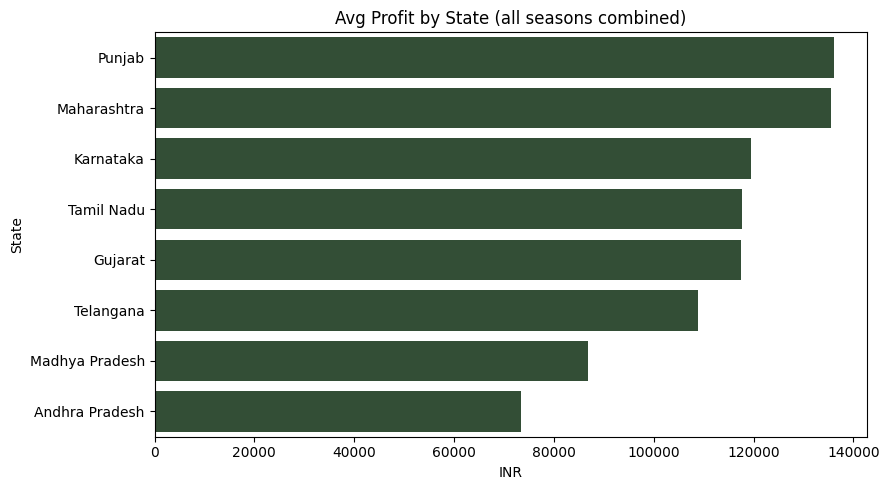

In [26]:
state_profit = df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False).round(0)

# color negative-average states differently - makes the loss-making states pop out immediately
bar_colors = ['#2F5233' if v > 0 else '#A8452F' for v in state_profit.values]

plt.figure(figsize=(9, 5))
sns.barplot(x=state_profit.values, y=state_profit.index, palette=bar_colors)
plt.title('Avg Profit by State (all seasons combined)')
plt.xlabel('INR')
plt.tight_layout()
plt.show()


In [27]:
state_season_profit = df.pivot_table(index='State', columns='Season',
                                      values='Profit_INR', aggfunc='mean').round(0)
state_season_profit = state_season_profit[SEASON_ORDER]
state_season_profit


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


Punjab and Maharashtra top the ranking, Andhra Pradesh lowest. The Kharif > Rabi > Zaid
ordering from earlier holds inside most individual states too, so it looks like a real
seasonal effect rather than one or two states dragging the average around.

## Statistical Significance Check

In [28]:
kharif_p = df.loc[df['Season'] == 'Kharif', 'Profit_INR']
rabi_p   = df.loc[df['Season'] == 'Rabi',   'Profit_INR']
zaid_p   = df.loc[df['Season'] == 'Zaid',   'Profit_INR']

f_stat, p_value = stats.f_oneway(kharif_p, rabi_p, zaid_p)
print(f'F = {f_stat:.2f}, p = {p_value:.6f}')

# standard ANOVA assumes roughly equal variance across groups - not formally tested here
# (e.g. Levene's test), so treat the p-value as indicative rather than exact
print('significant at 0.05' if p_value < 0.05 else 'not significant at 0.05')


F = 34.29, p = 0.000000
significant at 0.05


## Key Insights

1. Kharif is the strongest season - highest yield (~5.6 t/ha) and the only season with
   positive average profit (~Rs 1.79 lakh/farm).
2. Zaid is weakest financially - negative average profit, ~65% of farms loss-making,
   despite cost staying roughly flat across seasons. Shortfall is on revenue, not spend.
3. Zaid is also the hottest/driest season and leans more on Flood irrigation, the least
   efficient method - water efficiency is the strongest single driver of yield in the
   dataset, ahead of fertiliser and nitrogen.
4. Crop choice is season-dependent: Rice/Maize best in Kharif, Wheat best in Rabi,
   Pulses weakest everywhere.
5. Disease/pest risk peaks in Kharif (monsoon humidity) but doesn't appear to be
   eroding Kharif's profit lead at current levels.
6. Market price moves inversely with yield - a supply effect that partly offsets the
   benefit of a higher-yield season/crop.
7. The Kharif > Rabi > Zaid profit ordering holds across most states, and the ANOVA
   result supports it being a real seasonal effect rather than noise.

**Recommendations**
- Shift Zaid irrigation mix toward Drip/Rainfed, away from Flood.
- Re-evaluate Zaid crop selection - may suit drought-tolerant crops better than the
  current mix.
- Kharif's pest/disease risk is already elevated; targeted pest management could
  protect margins as risk increases.
- Don't assume higher yield = higher income automatically - the price-yield tradeoff
  means market access/timing matters too.

**Limitations**
- Dataset is a single-year snapshot (assumed) - no multi-year trend to confirm these
  patterns hold beyond this sample.
- ANOVA assumes equal variance across season groups; not separately verified here.
- Some fields (e.g. a subset of Water_Efficiency values) show suspiciously round
  numbers, possibly simulated/capped in the source data - didn't materially affect
  direction of the seasonal comparisons, but worth flagging for anyone extending this.